# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


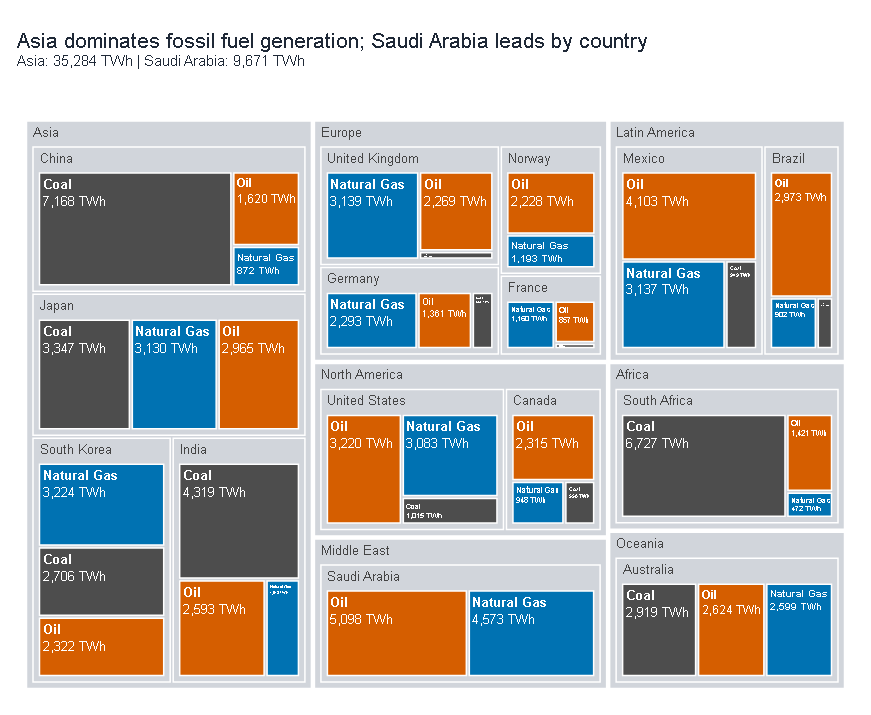

In [3]:
# Task 1 - Treemap: fossil fuel dependency by country

fossil_sources = ["Coal", "Oil", "Natural Gas"]

fossil_df = df.loc[df["Source_Type"] == "Fossil"].copy()

source_colors = {
    "Coal": "#4D4D4D",
    "Oil": "#D55E00",
    "Natural Gas": "#0072B2"
}

region_totals = fossil_df.groupby("Region", as_index=False)["TWh"].sum()
country_totals = fossil_df.groupby("Country", as_index=False)["TWh"].sum()

top_region = region_totals.loc[region_totals["TWh"].idxmax()]
top_country = country_totals.loc[country_totals["TWh"].idxmax()]

fig = px.treemap(
    fossil_df,
    path=["Region", "Country", "Source"],
    values="TWh",
    color="Source",
    color_discrete_map=source_colors,
    title=(
        f"Asia dominates fossil fuel generation; {top_country['Country']} leads by country"
        f"<br><sup>{top_region['Region']}: {top_region['TWh']:,.0f} TWh | "
        f"{top_country['Country']}: {top_country['TWh']:,.0f} TWh</sup>"
    )
)

parent_ids = set(fig.data[0].parents)

fig.update_traces(
    marker=dict(
        colors=[
            "#D1D5DB" if node_id in parent_ids else source_colors.get(label, "#D1D5DB")
            for node_id, label in zip(fig.data[0].ids, fig.data[0].labels)
        ],
        line=dict(color="white", width=1.5)
    ),
    texttemplate="<b>%{label}</b><br>%{value:,.0f} TWh",
    textfont=dict(size=13),
    hovertemplate="<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>",
    branchvalues="total"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=1050,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=20, r=20, t=95, b=20)
)

fig.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


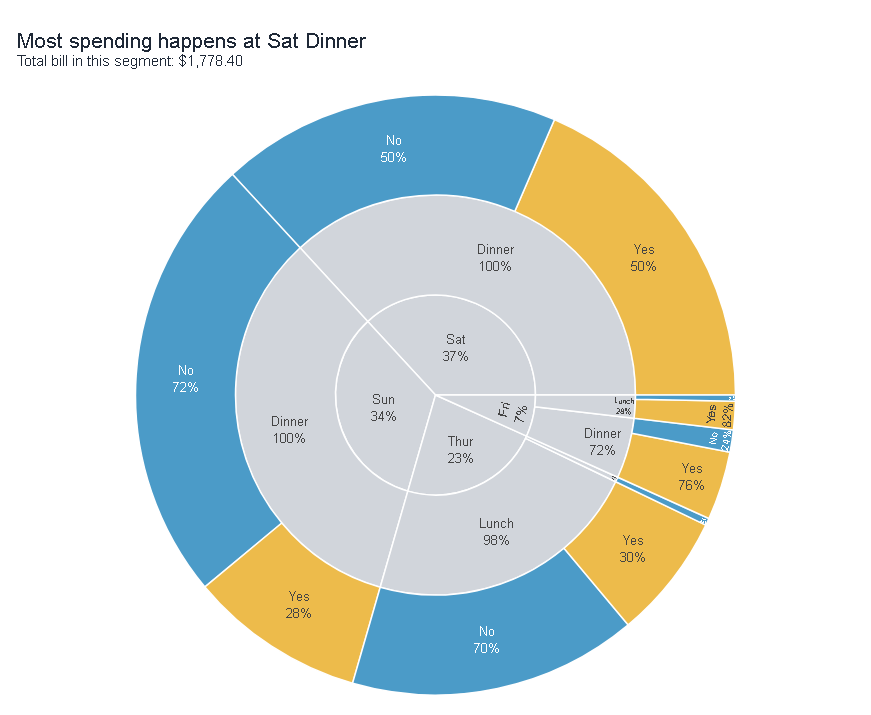

In [4]:
# Task 2 - Sunburst: tipping behaviour by day and meal time

tips = px.data.tips()

tips_agg = (
    tips
    .groupby(["day", "time", "smoker"], as_index=False)["total_bill"]
    .sum()
)

day_time_totals = (
    tips_agg
    .groupby(["day", "time"], as_index=False)["total_bill"]
    .sum()
    .sort_values("total_bill", ascending=False)
)

top_segment = day_time_totals.iloc[0]

smoker_colors = {
    "Yes": "#E69F00",
    "No": "#0072B2"
}

fig = px.sunburst(
    tips_agg,
    path=["day", "time", "smoker"],
    values="total_bill",
    color="smoker",
    color_discrete_map=smoker_colors,
    title=(
        f"Most spending happens at {top_segment['day']} {top_segment['time']}"
        f"<br><sup>Total bill in this segment: ${top_segment['total_bill']:,.2f}</sup>"
    )
)

parent_ids = set(fig.data[0].parents)

fig.update_traces(
    marker=dict(
        colors=[
            "#D1D5DB" if node_id in parent_ids else smoker_colors.get(label, "#D1D5DB")
            for node_id, label in zip(fig.data[0].ids, fig.data[0].labels)
        ],
        line=dict(color="white", width=1.5)
    ),
    textinfo="label+percent parent",
    hovertemplate="<b>%{label}</b><br>Total bill: $%{value:,.2f}<br>%{percentParent:.1%} of parent<extra></extra>",
    branchvalues="total"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=900,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=20, r=20, t=95, b=20)
)

fig.show()


## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


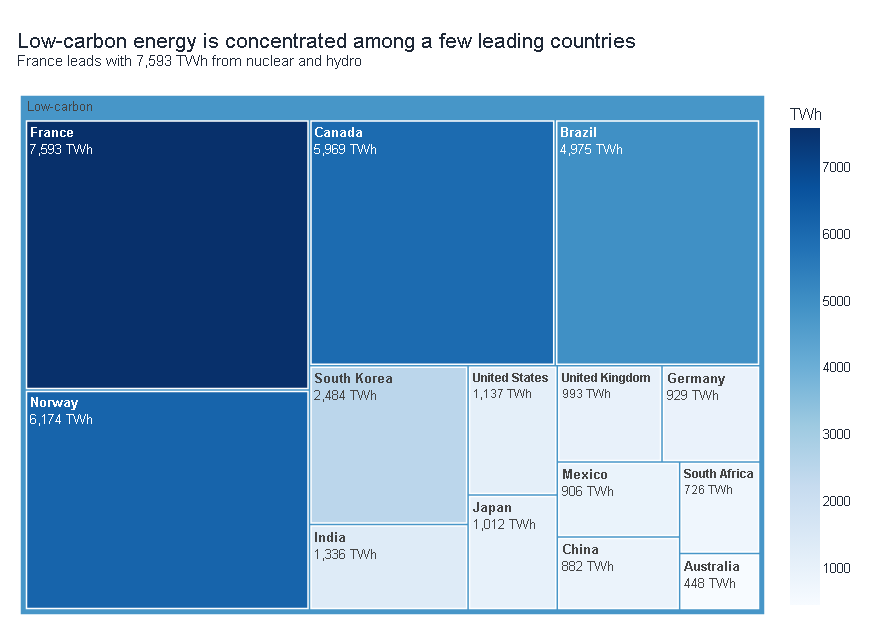

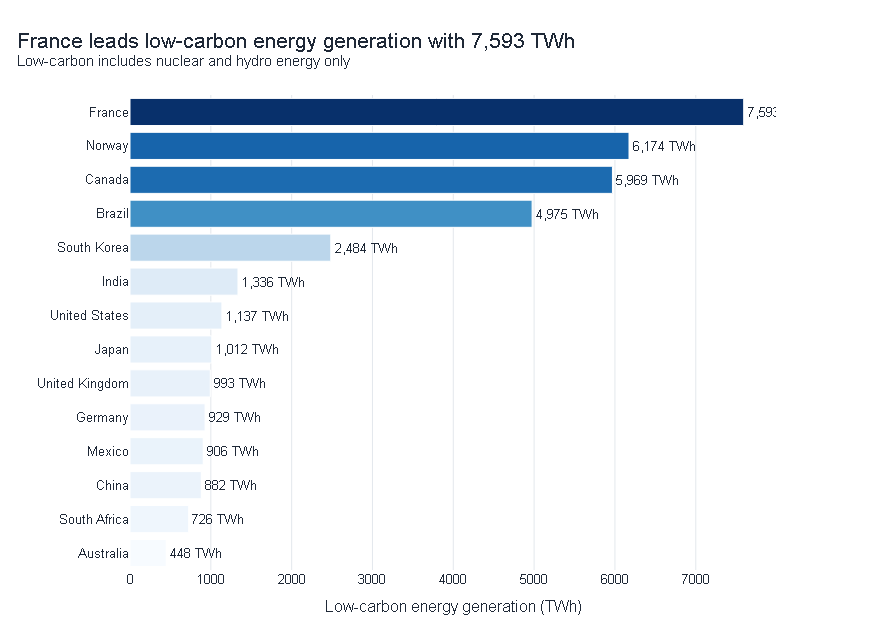

In [7]:
# Task 3 - Treemap vs bar: low-carbon energy by country

low_carbon_df = df.loc[df["Source_Type"] == "Low-carbon"].copy()

low_country = (
    low_carbon_df
    .groupby("Country", as_index=False)["TWh"]
    .sum()
    .sort_values("TWh", ascending=False)
)

low_country["All"] = "Low-carbon"

leader = low_country.iloc[0]

fig_tree = px.treemap(
    low_country,
    path=["All", "Country"],
    values="TWh",
    color="TWh",
    color_continuous_scale="Blues",
    title=(
        "Low-carbon energy is concentrated among a few leading countries"
        f"<br><sup>{leader['Country']} leads with {leader['TWh']:,.0f} TWh from nuclear and hydro</sup>"
    )
)

fig_tree.update_traces(
    texttemplate="<b>%{label}</b><br>%{value:,.0f} TWh",
    hovertemplate="<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>",
    marker=dict(line=dict(color="white", width=1.5)),
    branchvalues="total"
)

fig_tree.update_layout(
    template="plotly_white",
    height=620,
    width=950,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=20, r=20, t=95, b=20)
)

fig_tree.show()


low_country_bar = low_country.sort_values("TWh", ascending=True)

fig_bar = px.bar(
    low_country_bar,
    x="TWh",
    y="Country",
    orientation="h",
    color="TWh",
    color_continuous_scale="Blues",
    text="TWh",
    labels={
        "TWh": "Low-carbon energy generation (TWh)",
        "Country": "Country"
    },
    title=(
        f"France leads low-carbon energy generation with {leader['TWh']:,.0f} TWh"
        "<br><sup>Low-carbon includes nuclear and hydro energy only</sup>"
    )
)

fig_bar.update_traces(
    texttemplate="%{text:,.0f} TWh",
    textposition="outside",
    marker_line_color="white",
    marker_line_width=1
)

fig_bar.update_layout(
    template="plotly_white",
    height=620,
    width=950,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=130, r=95, t=95, b=65),
    coloraxis_showscale=False
)

fig_bar.update_xaxes(
    showgrid=True,
    gridcolor="rgba(148, 163, 184, 0.25)",
    zeroline=False
)

fig_bar.update_yaxes(title=None)

fig_bar.show()


## Key Insights

### Task 1: Fossil Fuel Dependency

The fossil fuel treemap shows that fossil energy generation is heavily concentrated in Asia. Asia has the largest fossil fuel total in the dataset, with approximately **35,284 TWh** from coal, oil, and natural gas combined.

At the country level, **Saudi Arabia** is the largest fossil fuel generator in this dataset, with approximately **9,671 TWh**, narrowly ahead of China. The treemap makes this concentration clear because the largest blocks are visually dominant.

Coal, oil, and natural gas are coloured separately so the chart shows not only which countries use the most fossil energy, but also which fossil source contributes most within each country.

### Task 2: Tipping Behaviour

The sunburst chart shows that total spending in the tips dataset is concentrated around dinner, especially on weekend days.

The largest spending segment is **Saturday dinner**, with total bill spending of approximately **$1,778.40**. This suggests that weekend dinner service is the strongest revenue period in the dataset.

Using smoker status as the colour category makes the final layer meaningful, while the grey parent nodes keep attention on the smoker and non-smoker split.

### Task 3: Low-Carbon Energy by Country

Low-carbon energy was defined as **nuclear plus hydro**. The treemap shows the part-to-whole structure, but the horizontal bar chart is clearer for ranking countries.

**France** leads low-carbon energy generation in this dataset with approximately **7,593 TWh**, followed by Norway and Canada.

For this task, the bar chart is the better final comparison because it makes the country ranking easier to read. The treemap is useful for seeing contribution size, but the bar chart communicates the leading country more directly.
